**علشان اعرف اى اهم الموديل الاكثر استخداما للغرض بتاعى **

In [1]:
from huggingface_hub import HfApi

api = HfApi()

models = api.list_models(
    filter="text-generation",
    sort="downloads",
    direction=-1,
    limit=5
)

for model in models:
    print(model.id, model.downloads)

Qwen/Qwen2.5-7B-Instruct 14966457
Qwen/Qwen3-0.6B 10207719
openai-community/gpt2 8152695
Qwen/Qwen2.5-1.5B-Instruct 6651765
meta-llama/Llama-3.1-8B-Instruct 5867664


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in 'list_models': direction. Will not be supported from version '1.5'.

Sorting is always descending.
  warnings.warn(message, FutureWarning)


In [2]:
from huggingface_hub import HfApi
help(HfApi.list_models)

Help on function list_models in module huggingface_hub.hf_api:

list_models(self, *, filter: 'Union[str, Iterable[str], None]' = None, author: 'Optional[str]' = None, apps: 'Optional[Union[str, list[str]]]' = None, gated: 'Optional[bool]' = None, inference: "Optional[Literal['warm']]" = None, inference_provider: "Optional[Union[Literal['all'], 'PROVIDER_T', list['PROVIDER_T']]]" = None, model_name: 'Optional[str]' = None, trained_dataset: 'Optional[Union[str, list[str]]]' = None, search: 'Optional[str]' = None, pipeline_tag: 'Optional[str]' = None, emissions_thresholds: 'Optional[tuple[float, float]]' = None, sort: 'Optional[ModelSort_T]' = None, direction: 'Optional[Literal[-1]]' = None, limit: 'Optional[int]' = None, expand: 'Optional[list[ExpandModelProperty_T]]' = None, full: 'Optional[bool]' = None, cardData: 'bool' = False, fetch_config: 'bool' = False, token: 'Union[bool, str, None]' = None) -> 'Iterable[ModelInfo]'
    List models hosted on the Huggingface Hub, given some filte

In [3]:
import gradio as gr
from transformers import pipeline

generator = pipeline("text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0")

def chat(prompt):
    return generator(prompt, max_new_tokens=100)[0]["generated_text"]

demo = gr.Interface(fn=chat, inputs="text", outputs="text")
demo.launch()

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://055025b497c789cb2c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
import torch
from transformers import pipeline

def load_model(model_name, task):
    
    device = 0 if torch.cuda.is_available() else -1
    
    pipe = pipeline(
        task,
        model=model_name,
        device=device
    )
    
    print(f"Loaded {model_name} on {'GPU' if device == 0 else 'CPU'}")
    
    return pipe

In [5]:
gen1 = load_model("TinyLlama/TinyLlama-1.1B-Chat-v1.0", "text-generation")


gen3 = load_model("distilbert-base-uncased", "text-classification")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded TinyLlama/TinyLlama-1.1B-Chat-v1.0 on GPU


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Loaded distilbert-base-uncased on GPU


In [6]:
from huggingface_hub import HfApi
api = HfApi()
from diffusers import StableDiffusionPipeline
models = api.list_models(
    filter=["text-to-image", "diffusers:StableDiffusionPipeline"],
    author="CompVis",
    sort="downloads"
)

models = list(models)

# Load the most popular model
pipe = StableDiffusionPipeline.from_pretrained(models[0].id)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/30 [00:00<?, ?it/s]

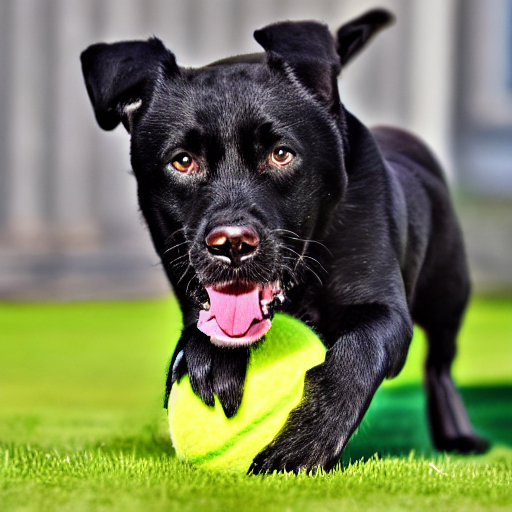

In [7]:
!pip install -q diffusers transformers accelerate safetensors
import torch
from diffusers import StableDiffusionPipeline

model_id = "CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,   # يقلل استهلاك الذاكرة
)

pipe = pipe.to("cuda")
pipe.enable_attention_slicing()  # يقلل استهلاك VRAM
prompt = "a black labrador chasing a tennis ball, high quality, detailed"

image = pipe(
    prompt,
    num_inference_steps=30,   # عدد خطوات التوليد
    guidance_scale=7.5        # مدى الالتزام بالبرومبت
).images[0]

image